In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/krakenteach13/ventas-tienda/Productos_vendidos_portienda .csv


In [16]:
import pandas as pd

# Cargamos el dataset solucionando el problema de la 'ñ' y manteniendo tu espacio exacto en la ruta
df_ventas = pd.read_csv("/kaggle/input/datasets/krakenteach13/ventas-tienda/Productos_vendidos_portienda .csv", encoding='latin1')

# Cambiamos df.head() por df_ventas.head() para llamar correctamente a tu variable
df_ventas.head()


# Muestra la lista completa de columnas
print("LISTA DE COLUMNAS DEL DATASET:\n" + "-"*35)
for col in df_ventas.columns:
    print(f" • {col}")

📋 LISTA DE COLUMNAS DEL DATASET:
-----------------------------------
 • fecha
 • tienda
 • categoria de producto
 • vendedor
 • producto
 • cantidad
 • precio
 • total


In [26]:
# 1. Agrupamos por tienda y calculamos el número de transacciones (count) y la suma del total (sum)
resumen_tiendas = df_ventas.groupby('tienda').agg(
    Numero_Transacciones=('total', 'count'),
    Total_Vendido=('total', 'sum')
).reset_index()

# 2. Ordenamos el resultado de Mayor a Menor usando la columna 'Total_Vendido'
resumen_tiendas = resumen_tiendas.sort_values(by='Total_Vendido', ascending=False)

# 3. Mostramos la tabla limpia en el notebook
resumen_tiendas


,tienda,Numero_Transacciones,Total_Vendido
4,Tienda E,107,463384.73
3,Tienda D,108,431107.13
0,Tienda A,101,424228.05
1,Tienda B,105,384941.41
2,Tienda C,79,331483.41


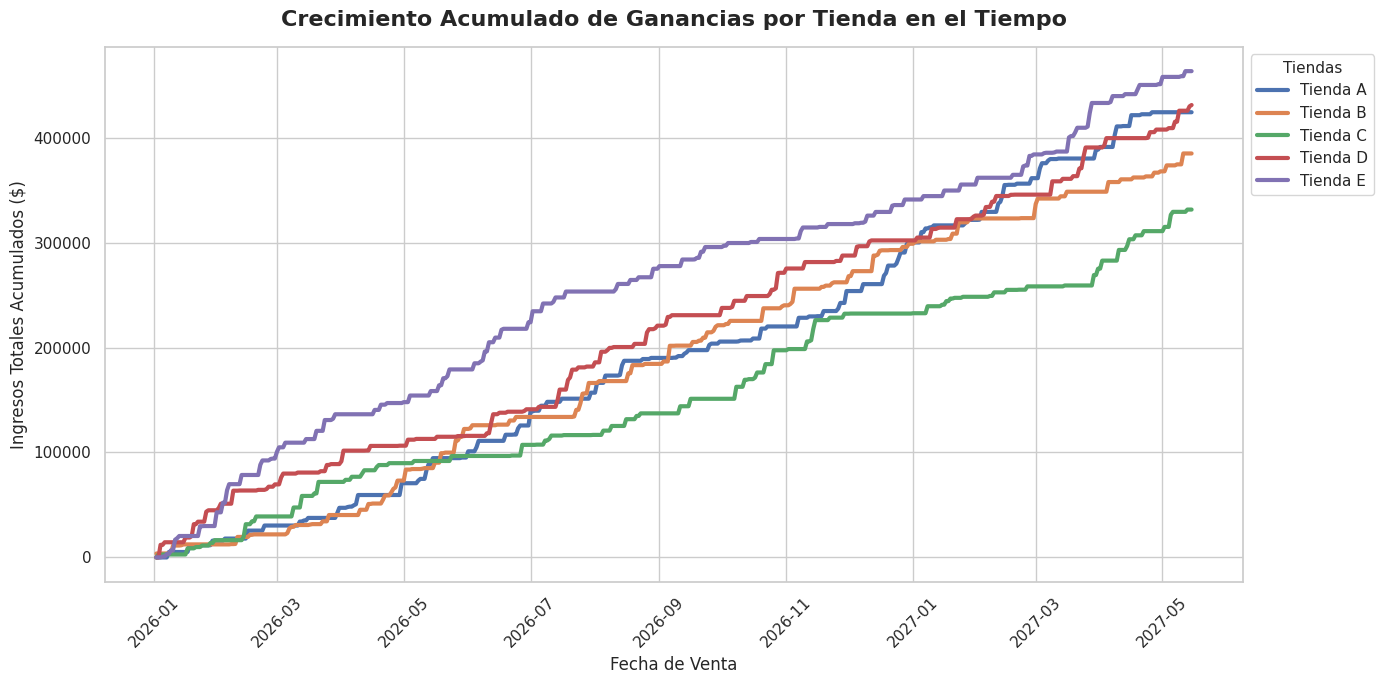

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aseguramos formato de fecha y orden cronológico
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_ventas = df_ventas.sort_values('fecha')

# 2. Agrupamos por fecha y tienda para tener los totales diarios de cada una
ventas_diarias = df_ventas.groupby(['fecha', 'tienda'])['total'].sum().unstack(fill_value=0)

# 3. Calculamos la suma acumulada en el tiempo para cada tienda
ventas_acumuladas = ventas_diarias.cumsum()

# 4. Convertimos los datos de nuevo a formato largo para que Seaborn lo entienda más fácil
ventas_acumuladas_long = ventas_acumuladas.stack().reset_index(name='Total_Acumulado')

# 5. Configuramos el diseño visual de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 6. Dibujamos las líneas acumulativas (una por tienda con color individual usando 'hue')
sns.lineplot(
    data=ventas_acumuladas_long, 
    x='fecha', 
    y='Total_Acumulado', 
    hue='tienda',
    linewidth=3          # Líneas gruesas y profesionales
)

# 7. Personalizamos títulos y etiquetas
plt.title('Crecimiento Acumulado de Ganancias por Tienda en el Tiempo', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Fecha de Venta', fontsize=12)
plt.ylabel('Ingresos Totales Acumulados ($)', fontsize=12)

plt.xticks(rotation=45)
plt.legend(title='Tiendas', title_fontsize='11', loc='upper left', bbox_to_anchor=(1, 1))

# Mostramos el resultado impecable en pantalla
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/3020518068.py:48: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
/tmp/ipykernel_58/3020518068.py:48: UserWarning: Glyph 151 (\x97) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 151 (\x97) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 151 (\x97) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


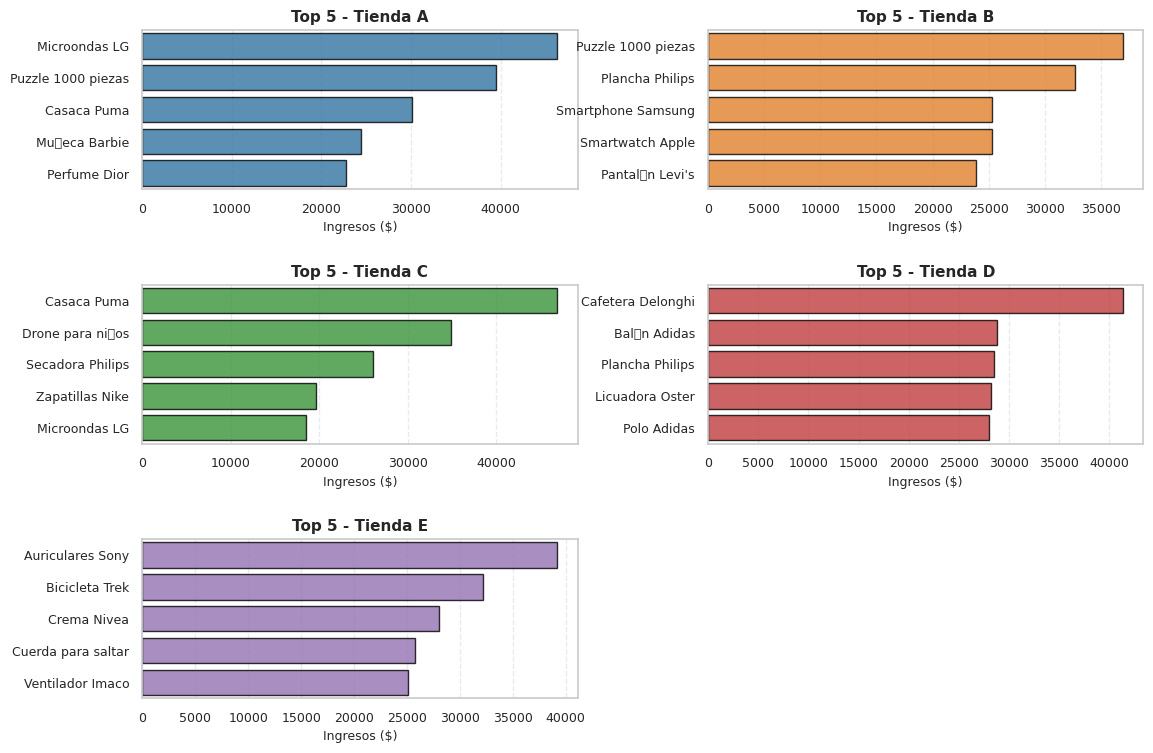

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupamos por tienda y producto para calcular el total vendido
productos_tienda = df_ventas.groupby(['tienda', 'producto'])['total'].sum().reset_index()
lista_tiendas = productos_tienda['tienda'].unique()
num_tiendas = len(lista_tiendas)

# 2. Configuramos la cuadrícula: 2 columnas, y las filas necesarias según el número de tiendas
# Al usar figsize=(12, 8) para la ventana completa, cada subgráfico se encoge automáticamente
fig, axes = plt.subplots(nrows=(num_tiendas + 1) // 2, ncols=2, figsize=(12, 8))

# Convertimos la matriz de ejes en una lista plana para recorrerla fácilmente con el bucle
axes = axes.flatten()

# 3. Definimos los colores para cada tienda
colores_tiendas = sns.color_palette("tab10", num_tiendas)

# 4. Construimos los gráficos juntos dentro de la cuadrícula
for i, tienda in enumerate(lista_tiendas):
    # Filtrar y obtener el Top 5 de la tienda actual
    datos_tienda = productos_tienda[productos_tienda['tienda'] == tienda]
    top_5 = datos_tienda.sort_values(by='total', ascending=False).head(5)
    
    # Dibujamos en el eje (cuadro) correspondiente: ax=axes[i]
    sns.barplot(
        data=top_5,
        x='total',
        y='producto',
        color=colores_tiendas[i],
        edgecolor='black',
        alpha=0.8,
        ax=axes[i] 
    )
    
    # Personalización individual minimalista para ahorrar espacio
    axes[i].set_title(f'Top 5 - {tienda}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Ingresos ($)', fontsize=9)
    axes[i].set_ylabel('', fontsize=9)  # Quitamos la etiqueta repetitiva de "Producto"
    axes[i].tick_params(labelsize=9)     # Achicamos el tamaño de la letra de los productos
    axes[i].grid(True, axis='x', linestyle='--', alpha=0.4)

# 5. 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=2.0)
plt.subplots_adjust(hspace=0.6, wspace=0.3)

In [36]:
# Agrupamos por vendedor para calcular métricas clave
rendimiento_vendedores = df_ventas.groupby('vendedor').agg(
    Total_Vendido=('total', 'sum'),
    Cantidad_Articulos=('cantidad', 'sum'),
    Transacciones=('total', 'count')
).reset_index()

# Calculamos el ticket promedio por transacción de cada uno
rendimiento_vendedores['Ticket_Promedio'] = rendimiento_vendedores['Total_Vendido'] / rendimiento_vendedores['Transacciones']

# Ordenamos por el que más dinero generó
rendimiento_vendedores = rendimiento_vendedores.sort_values(by='Total_Vendido', ascending=False)
rendimiento_vendedores

,vendedor,Total_Vendido,Cantidad_Articulos,Transacciones,Ticket_Promedio
2,Jos,293871.59,393,63,4664.628413
6,Pedro,291807.96,362,67,4355.342687
5,Mara,271861.99,348,66,4119.121061
3,Luca,261117.13,345,72,3626.626806
0,Ana,259181.09,309,54,4799.649815
1,Carlos,255771.37,306,68,3761.343676
4,Luis,213368.30,353,60,3556.138333
7,Rosa,188165.30,278,50,3763.306000


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 151 (\x97) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 151 (\x97) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


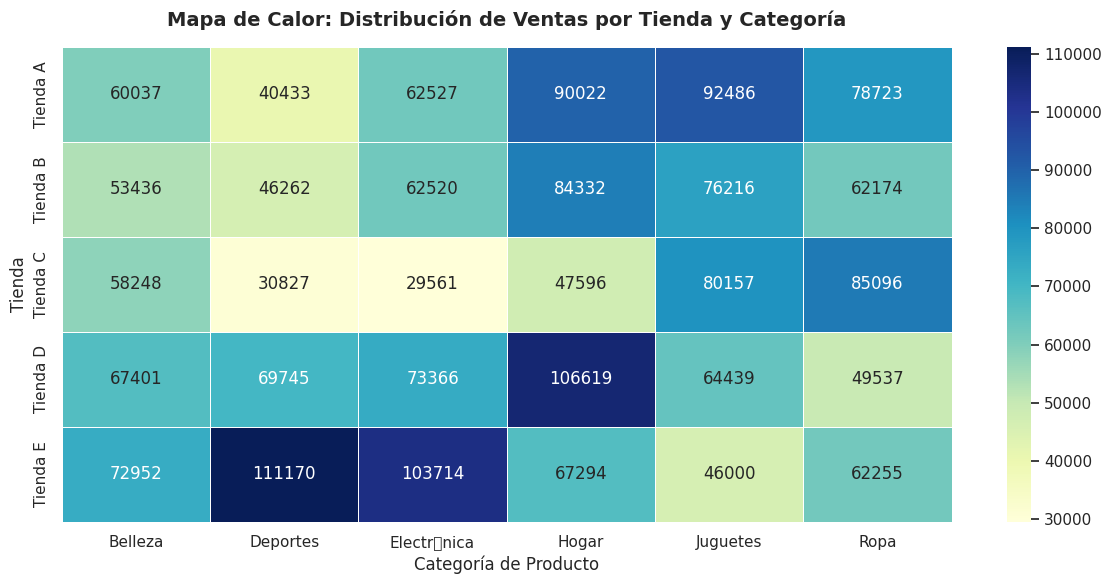

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos una tabla cruzada (Pivot Table) entre Tienda y Categoría
matriz_tienda_cat = df_ventas.pivot_table(
    index='tienda', 
    columns='categoria de producto', 
    values='total', 
    aggfunc='sum', 
    fill_value=0
)

# 2. Dibujamos el mapa de calor
plt.figure(figsize=(12, 6))
sns.heatmap(matriz_tienda_cat, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)

plt.title('Mapa de Calor: Distribución de Ventas por Tienda y Categoría', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoría de Producto')
plt.ylabel('Tienda')
plt.tight_layout()
plt.show()

In [38]:
# Analizar el comportamiento de compra general del negocio
print(f" Ticket Promedio de Compra: ${df_ventas['total'].mean():.2f}")
print(f" Unidades Promedio por Transacción: {df_ventas['cantidad'].mean():.1f} unidades")
print(f" Precio Promedio de los Productos: ${df_ventas['precio'].mean():.2f}")

 Ticket Promedio de Compra: $4070.29
 Unidades Promedio por Transacción: 5.4 unidades
 Precio Promedio de los Productos: $751.21


/tmp/ipykernel_58/929753096.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_dias, x='dia_semana', y='total', palette='Blues_r', edgecolor='black')


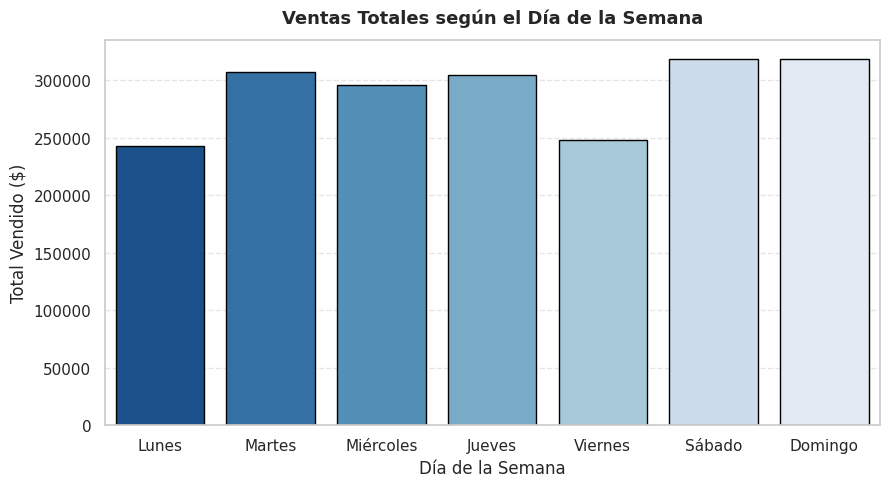

In [39]:
# 1. Extraemos el nombre del día de la semana basado en la fecha
df_ventas['dia_semana'] = df_ventas['fecha'].dt.day_name()

# 2. Agrupamos y ordenamos cronológicamente (de lunes a domingo)
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dias = df_ventas.groupby('dia_semana')['total'].sum().reindex(orden_dias).reset_index()

# Traducimos los nombres para que tu reporte quede impecable en español
dias_espanol = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles', 
                'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}
ventas_dias['dia_semana'] = ventas_dias['dia_semana'].map(dias_espanol)

# 3. Graficamos
plt.figure(figsize=(10, 5))
sns.barplot(data=ventas_dias, x='dia_semana', y='total', palette='Blues_r', edgecolor='black')
plt.title('Ventas Totales según el Día de la Semana', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Día de la Semana')
plt.ylabel('Total Vendido ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()